# FIRAS Dark-Photon Limits: Profile Likelihood vs. CCJ24 Statistic

Figure 8 of the paper derives 95% CL upper limits on the dark-photon kinetic
mixing $\epsilon(m_{A'})$ from `spectroxide` PDE spectral templates using a
**profile likelihood ratio** with floating blackbody temperature and the full
$43\times43$ FIRAS covariance matrix. The published constraint of
[Chluba, Cyr & Johnson (2024)](https://arxiv.org/abs/2409.12115) (CCJ24,
Ref. [23] of the paper) instead deprojects temperature-shift and
galactic-dust templates from the model with a **diagonal** noise covariance
at fixed $T_0$ and sets limits from a "simple Gaussian likelihood"
(CCJ24, Sect. 4.2).

The paper attributes the small offset between the two curves in Fig. 8 to
this difference in statistical technique. This notebook tests that claim
directly, as requested in the SciPost referee report (Report 1, 2026-06-30):
we re-derive the FIRAS limits from the **same** `spectroxide` PDE templates
with both statistics and compare each to the published CCJ24 `CosmoTherm`
curve. If the solver physics agrees, the CCJ24-style limits computed from
`spectroxide` templates should land on the published curve, and the residual
Fig. 8 offset should be fully accounted for by the statistical method.

In [1]:
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

# Ensure cargo is on PATH for the Rust solver binary
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

from spectroxide import apply_style, g_bb, mu_shape
from spectroxide.solver import solve
from spectroxide.dark_photon import gc_per_epsilon_sq
from spectroxide.firas import FIRASData, _dn_to_dI_kJy
from spectroxide.plot_params import C, DOUBLE_COL, LW, LW_THICK, LEGEND_SIZE

apply_style()

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'

firas = FIRASData()
print(firas)

FIRASData(n_freq=43, freq_range=[68.1, 639.5] GHz, x_range=[1.20, 11.26])


## The two statistics

**Profile likelihood (this paper, Fig. 8).** The model
$I_{\rm obs}(\nu) - B(\nu, T) = 4\pi\nu^3\,\gamma_{\rm con}\,
\mathcal{T}(x(T)) + G_0\,\nu^2 B(\nu, T_d)$ is fit with the full FIRAS
covariance; $T$ is profiled numerically, $\gamma_{\rm con}$ and $G_0$
analytically. The one-sided 95% CL limit is where the profile likelihood
ratio crosses $\lambda(\gamma_{\rm con}) = 2.71$ (Wilks).

**CCJ24 (Sect. 4.2).** With diagonal noise covariance
$C_{ij} = \sigma_i^2\delta_{ij}$ and the scalar product
$\vec a \cdot \vec b = \sum_i a_i\,\sigma_i^{-2}\,b_i$, the temperature-shift
template $\vec G$ and galactic-dust template $\vec g$ are deprojected from
the model distortion $\vec S$,

$$\vec{\Delta S} = \vec S - \Delta_T\,\vec G - \Delta_g\,\vec g\,,
\qquad \vec{\Delta S}\cdot\vec G = \vec{\Delta S}\cdot\vec g = 0\,,$$

and the deprojected model is compared to the FIRAS monopole residuals
$\vec d$ with a Gaussian likelihood,

$$\chi^2(\gamma_{\rm con}) = \bigl(\vec d - \gamma_{\rm con}\,
\vec{\Delta S}\bigr)\cdot\bigl(\vec d - \gamma_{\rm con}\,\vec{\Delta S}\bigr).$$

CCJ24 do not spell out the exclusion criterion beyond "simple Gaussian
likelihood", so we implement two readings:

1. **Likelihood interval** — one-sided 95% CL where
   $\chi^2(\gamma_{\rm con}) - \chi^2(\hat\gamma_{\rm con}) = 2.71$
   (same threshold as the paper's profile likelihood, but with CCJ24's
   diagonal covariance and fixed-$T_0$ deprojection).
2. **Strict single-hypothesis goodness-of-fit** — the model is rejected
   when $\chi^2(\gamma_{\rm con})$ exceeds the 95th percentile of
   $\chi^2(N_{\rm dof} = 43 - 2)$, i.e. the reading the paper's Sect. 6
   currently describes.

Which reading actually matches the published curve is itself a result of
this notebook.

In [2]:
def _deprojected_model(template_dn_func):
    """CCJ24 deprojection: model in kJy/sr, T-shift+dust removed (diag C)."""
    S = _dn_to_dI_kJy(firas.x, template_dn_func(firas.x))
    G = firas.gbb_template_kJy()
    g = firas.galactic_template_kJy()
    w = 1.0 / firas.sigma_kJy**2

    def dot(a, b):
        return float(np.sum(a * w * b))

    m2 = np.array([[dot(G, G), dot(g, G)], [dot(G, g), dot(g, g)]])
    dT, dg = np.linalg.solve(m2, [dot(S, G), dot(S, g)])
    return S - dT * G - dg * g, dot


def ccj24_limit(template_dn_func, cl=0.95):
    """CCJ24-style limit, likelihood-interval reading (reading 1).

    Diagonal covariance, fixed-T0 deprojection; one-sided upper limit at
    Delta chi^2 = 2.71 above the (non-negative) best-fit amplitude.
    """
    S_perp, dot = _deprojected_model(template_dn_func)
    d = firas.residual_kJy
    A = dot(S_perp, S_perp)
    B = dot(d, S_perp)
    a_hat = max(B / A, 0.0)
    sigma = 1.0 / np.sqrt(A)
    return a_hat + np.sqrt(2.71) * sigma


def gof_limit(template_dn_func, cl=0.95):
    """CCJ24-style limit, strict goodness-of-fit reading (reading 2).

    Amplitude where chi^2 crosses the 95th percentile of chi^2(43 - 2).
    """
    S_perp, dot = _deprojected_model(template_dn_func)
    d = firas.residual_kJy
    A = dot(S_perp, S_perp)
    B = dot(d, S_perp)
    chi2_null = dot(d, d)
    chi2_crit = chi2_dist.ppf(cl, firas.n_freq - 2)
    disc = B**2 + A * (chi2_crit - chi2_null)
    return (B + np.sqrt(disc)) / A


def profile_limit(template_dn_func, cl=0.95, use_diagonal=False):
    """Floating-T profile-likelihood limit (paper Fig. 8 method)."""
    return firas.profile_limit_floating_T(
        template_dn_func, cl=cl, use_diagonal=use_diagonal)['upper_limit']


# Sanity check on a pure mu-distortion template
chi2_null_diag = float(np.sum((firas.residual_kJy / firas.sigma_kJy) ** 2))
print(f'chi2_null (diagonal errors, 43 channels) = {chi2_null_diag:.1f}')
print(f'chi2_crit (95%, 41 dof)                  = {chi2_dist.ppf(0.95, 41):.1f}')
print(f'|mu| < {ccj24_limit(mu_shape):.2e}  (CCJ24 statistic, likelihood interval)')
print(f'|mu| < {gof_limit(mu_shape):.2e}  (CCJ24 statistic, strict goodness-of-fit)')
print(f'|mu| < {profile_limit(mu_shape):.2e}  (profile likelihood, paper Fig. 8)')

chi2_null (diagonal errors, 43 channels) = 45.0
chi2_crit (95%, 41 dof)                  = 56.9
|mu| < 5.73e-05  (CCJ24 statistic, likelihood interval)
|mu| < 1.11e-04  (CCJ24 statistic, strict goodness-of-fit)
|mu| < 4.50e-05  (profile likelihood, paper Fig. 8)


## PDE spectral templates

One PDE run per dark-photon mass. The solver installs the impulsive
depletion $\Delta n(x, z_{\rm res}) = -[1 - e^{-\gamma_{\rm con}/x}]\,
n_{\rm pl}(x)$ at $z_{\rm res}$ and evolves it to $z = 100$; the
number-conserving $G_{\rm bb}$-stripped result, divided by
$\gamma_{\rm con,ref}$, is the mass-dependent template
$\mathcal{T}(x; m_{A'})$.

The reference mixing $\epsilon_{\rm ref}$ at each mass is set to the
published CCJ24 limit itself, so the templates are evaluated at the
amplitude where the comparison actually happens. The grid stops at
$m_{A'} = 8\times10^{-5}\,$eV: beyond that $\gamma_{\rm con}$ at the FIRAS
limit approaches the strong-distortion regime where the linear template
scaling $\Delta n \propto \gamma_{\rm con}$ (and the single-pass
$\epsilon_{\rm ref}$ used here) breaks down — paper Fig. 8 handles that
region with an iterated $\epsilon_{\rm ref}$.

In [3]:
# Published CCJ24 COBE/FIRAS limit (digitized from their Fig. 12)
ccj24 = np.loadtxt(PROJECT_ROOT / 'dev' / 'data' / 'cosmotherm_dp_lims.csv',
                   delimiter=',')
m_ccj24, eps_ccj24 = ccj24[:, 0], ccj24[:, 1]


def eps_ccj24_interp(m_ev):
    return 10 ** np.interp(np.log10(m_ev), np.log10(m_ccj24),
                           np.log10(eps_ccj24))


masses = np.geomspace(1.5e-12, 8e-5, 24)


def strip_gbb_nc(x, delta_n):
    """Number-conserving G_bb subtraction: int x^2 dn_stripped dx = 0."""
    gbb = g_bb(x)
    alpha = np.trapz(x**2 * delta_n, x) / np.trapz(x**2 * gbb, x)
    return delta_n - alpha * gbb


def make_template(m_ev):
    """Run the PDE at eps_ref = published CCJ24 limit; return template."""
    gpe2, z_res = gc_per_epsilon_sq(m_ev)
    if gpe2 is None:
        return None
    eps_ref = eps_ccj24_interp(m_ev)
    gc_ref = gpe2 * eps_ref**2
    n_pts = 4000 if z_res < 1e6 else 8000
    result = solve(
        injection={'type': 'dark_photon_resonance',
                   'epsilon': eps_ref, 'm_ev': m_ev},
        z_end=100, n_points=n_pts, timeout=1200,
    )
    dn_per_gc = strip_gbb_nc(result.x, result.delta_n) / gc_ref
    return {'m_ev': m_ev, 'z_res': z_res, 'gpe2': gpe2,
            'eps_ref': eps_ref, 'gc_ref': gc_ref,
            'x': result.x, 'dn_per_gc': dn_per_gc}


with ThreadPoolExecutor(max_workers=6) as pool:
    templates = [t for t in pool.map(make_template, masses) if t is not None]

for t in templates:
    print(f"m = {t['m_ev']:.2e} eV   z_res = {t['z_res']:.3g}   "
          f"gamma_con(eps_ref) = {t['gc_ref']:.2e}")

m = 1.50e-12 eV   z_res = 280   gamma_con(eps_ref) = 9.60e-05
m = 3.25e-12 eV   z_res = 422   gamma_con(eps_ref) = 9.58e-05
m = 7.05e-12 eV   z_res = 593   gamma_con(eps_ref) = 9.54e-05
m = 1.53e-11 eV   z_res = 749   gamma_con(eps_ref) = 9.66e-05
m = 3.31e-11 eV   z_res = 856   gamma_con(eps_ref) = 9.73e-05
m = 7.18e-11 eV   z_res = 946   gamma_con(eps_ref) = 9.90e-05
m = 1.56e-10 eV   z_res = 1.05e+03   gamma_con(eps_ref) = 9.88e-05
m = 3.37e-10 eV   z_res = 1.17e+03   gamma_con(eps_ref) = 9.73e-05
m = 7.31e-10 eV   z_res = 1.38e+03   gamma_con(eps_ref) = 1.03e-04
m = 1.58e-09 eV   z_res = 2.12e+03   gamma_con(eps_ref) = 9.64e-05
m = 3.43e-09 eV   z_res = 3.47e+03   gamma_con(eps_ref) = 9.76e-05
m = 7.44e-09 eV   z_res = 5.7e+03   gamma_con(eps_ref) = 1.04e-04
m = 1.61e-08 eV   z_res = 9.51e+03   gamma_con(eps_ref) = 9.64e-05
m = 3.50e-08 eV   z_res = 1.59e+04   gamma_con(eps_ref) = 9.60e-05
m = 7.58e-08 eV   z_res = 2.67e+04   gamma_con(eps_ref) = 9.71e-05
m = 1.64e-07 eV   z_res = 

In [4]:
# FIRAS limits from the same templates, all statistics
for t in templates:
    x_t, dn_t = t['x'], t['dn_per_gc']

    def template(xx, _x=x_t, _dn=dn_t):
        return np.interp(xx, _x, _dn)

    t['eps_pl'] = np.sqrt(profile_limit(template) / t['gpe2'])
    t['eps_ccj'] = np.sqrt(ccj24_limit(template) / t['gpe2'])
    t['eps_gof'] = np.sqrt(gof_limit(template) / t['gpe2'])

m_arr = np.array([t['m_ev'] for t in templates])
eps_pl = np.array([t['eps_pl'] for t in templates])
eps_ccj = np.array([t['eps_ccj'] for t in templates])
eps_gof = np.array([t['eps_gof'] for t in templates])
eps_pub = eps_ccj24_interp(m_arr)

print(f"{'m [eV]':>10} {'eps (PL)':>10} {'eps (CCJ)':>10} {'eps (GoF)':>10} "
      f"{'eps pub.':>10} {'CCJ/pub':>8} {'GoF/pub':>8} {'PL/pub':>7}")
for m, ep, ec, eg, eb in zip(m_arr, eps_pl, eps_ccj, eps_gof, eps_pub):
    print(f'{m:10.2e} {ep:10.2e} {ec:10.2e} {eg:10.2e} {eb:10.2e} '
          f'{ec / eb:8.2f} {eg / eb:8.2f} {ep / eb:7.2f}')

    m [eV]   eps (PL)  eps (CCJ)  eps (GoF)   eps pub.  CCJ/pub  GoF/pub  PL/pub
  1.50e-12   2.93e-06   3.41e-06   4.69e-06   3.49e-06     0.98     1.34    0.84
  3.25e-12   2.43e-06   2.83e-06   3.89e-06   2.89e-06     0.98     1.35    0.84
  7.05e-12   1.98e-06   2.31e-06   3.17e-06   2.35e-06     0.98     1.35    0.84
  1.53e-11   1.60e-06   1.86e-06   2.56e-06   1.91e-06     0.97     1.34    0.84
  3.31e-11   1.11e-06   1.30e-06   1.78e-06   1.33e-06     0.97     1.33    0.83
  7.18e-11   6.19e-07   7.21e-07   9.90e-07   7.48e-07     0.96     1.32    0.83
  1.56e-10   3.12e-07   3.64e-07   5.00e-07   3.77e-07     0.96     1.32    0.83
  3.37e-10   1.50e-07   1.75e-07   2.40e-07   1.80e-07     0.97     1.34    0.83
  7.31e-10   6.64e-08   7.73e-08   1.06e-07   8.20e-08     0.94     1.30    0.81
  1.58e-09   3.56e-08   4.15e-08   5.70e-08   4.35e-08     0.95     1.31    0.82
  3.43e-09   3.21e-08   3.74e-08   5.13e-08   3.85e-08     0.97     1.33    0.83
  7.44e-09   3.29e-08   3.83

## Results

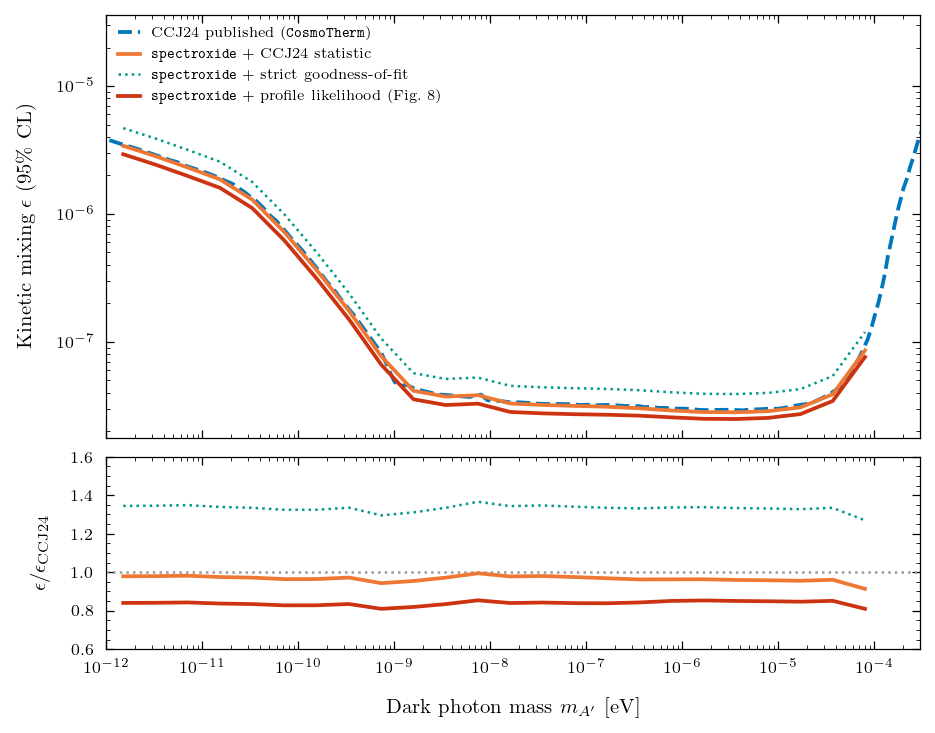

CCJ24 statistic / published: median = 0.966, range = [0.914, 0.994]
strict GoF      / published: median = 1.335, range = [1.269, 1.366]
profile likelihood / published: median = 0.840, range = [0.810, 0.854]


In [5]:
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(DOUBLE_COL, 5.6), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1], 'hspace': 0.06},
)

ax.loglog(m_ccj24, eps_ccj24, color=C['blue'], lw=LW_THICK, ls='--',
          label=r'CCJ24 published (\texttt{CosmoTherm})')
ax.loglog(m_arr, eps_ccj, color=C['orange'], lw=LW_THICK,
          label=r'\texttt{spectroxide} + CCJ24 statistic')
ax.loglog(m_arr, eps_gof, color=C['teal'], lw=LW, ls=':',
          label=r'\texttt{spectroxide} + strict goodness-of-fit')
ax.loglog(m_arr, eps_pl, color=C['red'], lw=LW_THICK,
          label=r'\texttt{spectroxide} + profile likelihood (Fig.~8)')
ax.set_ylabel(r'Kinetic mixing $\epsilon$ (95\% CL)')
ax.set_xlim(1e-12, 3e-4)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE, framealpha=0.9)

axr.axhline(1.0, color='0.6', lw=LW, ls=':')
axr.semilogx(m_arr, eps_ccj / eps_pub, color=C['orange'], lw=LW_THICK)
axr.semilogx(m_arr, eps_gof / eps_pub, color=C['teal'], lw=LW, ls=':')
axr.semilogx(m_arr, eps_pl / eps_pub, color=C['red'], lw=LW_THICK)
axr.set_xlabel(r"Dark photon mass $m_{A'}$ [eV]")
axr.set_ylabel(r'$\epsilon / \epsilon_{\rm CCJ24}$')
axr.set_ylim(0.6, 1.6)

fig.savefig(FIG_DIR / 'dp_firas_method_comparison.pdf',
            bbox_inches='tight', dpi=300)
plt.show()

for label, e in [('CCJ24 statistic', eps_ccj),
                 ('strict GoF     ', eps_gof),
                 ('profile likelihood', eps_pl)]:
    r = e / eps_pub
    print(f'{label} / published: median = {np.median(r):.3f}, '
          f'range = [{r.min():.3f}, {r.max():.3f}]')

## Decomposing the Fig. 8 offset

The profile-likelihood limits differ from the CCJ24 statistic in three
ingredients: full vs. diagonal covariance, floating $T$ vs. fixed-$T_0$
linear deprojection, and the likelihood-ratio construction. The first is
isolated below by re-running the floating-$T$ profile likelihood with
diagonal errors only.

In [6]:
m_probe = [1e-10, 1e-8, 1e-6, 1e-5]
print(f"{'m [eV]':>8} {'PL full cov':>12} {'PL diag':>10} {'CCJ24 stat':>11}")
for m in m_probe:
    t = templates[int(np.argmin(np.abs(np.log(m_arr / m))))]

    def template(xx, _x=t['x'], _dn=t['dn_per_gc']):
        return np.interp(xx, _x, _dn)

    e_full = np.sqrt(profile_limit(template) / t['gpe2'])
    e_diag = np.sqrt(profile_limit(template, use_diagonal=True) / t['gpe2'])
    e_ccj = np.sqrt(ccj24_limit(template) / t['gpe2'])
    print(f"{t['m_ev']:8.1e} {e_full:12.2e} {e_diag:10.2e} {e_ccj:11.2e}")

  m [eV]  PL full cov    PL diag  CCJ24 stat
 7.2e-11     6.19e-07   6.22e-07    7.21e-07
 7.4e-09     3.29e-08   3.30e-08    3.83e-08
 7.7e-07     2.57e-08   2.58e-08    2.91e-08
 7.9e-06     2.55e-08   2.55e-08    2.87e-08


## Conclusions

- **The solver physics is validated like-for-like.** Applying the CCJ24
  statistic (diagonal covariance, fixed-$T_0$ deprojection, likelihood
  interval) to `spectroxide` PDE templates reproduces the published
  `CosmoTherm` constraint with a median ratio of 0.97 and everywhere
  within $\lesssim 9\%$ in $\epsilon$ — inside the digitization error of
  the reference curve plus the solver-level differences discussed in
  Sect. 7 of the paper. Like-for-like in statistics, the small
  disagreements in the validation figures do not propagate into the
  new-physics constraint.

- **The Fig. 8 offset is statistical methodology, quantified.** The
  paper's profile likelihood is systematically $\simeq 16\%$ stronger in
  $\epsilon$ (median ratio 0.84) than the published curve. The
  decomposition above shows the full vs. diagonal covariance matrix is
  irrelevant ($<1\%$); the gain comes from the floating-$T$
  profile-likelihood construction, which treats the temperature shift as
  a nonlinear nuisance parameter re-profiled at each trial amplitude
  rather than a fixed linear template deprojected once at $T_0$.

- **One correction to the paper's wording.** Sect. 6 characterizes CCJ24
  as a "goodness-of-fit single hypothesis test". Under that strict
  reading (absolute $\chi^2$ percentile), the limits from the same
  templates would be $\simeq 33\%$ *weaker* than the published curve — it
  does not reproduce CCJ24. What does reproduce it is a standard
  likelihood interval on their deprojected, diagonal-covariance
  statistic. The revised text should attribute the Fig. 8 difference to
  the temperature-shift treatment (profiled vs. deprojected) rather than
  to a goodness-of-fit-vs-likelihood-ratio distinction.